In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [19]:
import os

print(os.path.exists(r"C:\bluestock_mf_capstone\data\processed\nav_history_clean.csv"))

True


In [20]:
nav = pd.read_csv(r"C:\bluestock_mf_capstone\data\processed\nav_history_clean.csv")

In [21]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt

nav = pd.read_csv(r"C:\bluestock_mf_capstone\data\processed\nav_history_clean.csv")
nifty100 = pd.read_csv(r"C:\bluestock_mf_capstone\data\processed\nifty100.csv")
nifty50 = pd.read_csv(r"C:\bluestock_mf_capstone\data\processed\nifty50.csv")

nav["date"] = pd.to_datetime(nav["date"])
nifty100["date"] = pd.to_datetime(nifty100["date"])
nifty50["date"] = pd.to_datetime(nifty50["date"])

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\bluestock_mf_capstone\\data\\processed\\nifty100.csv'

In [22]:
nifty100 = pd.read_csv(r"C:\bluestock_mf_capstone\data\processed\nifty100_clean.csv")
nifty50 = pd.read_csv(r"C:\bluestock_mf_capstone\data\processed\nifty50_clean.csv")


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\bluestock_mf_capstone\\data\\processed\\nifty100_clean.csv'

In [23]:
import os

print(os.listdir(r"C:\bluestock_mf_capstone\data"))
print(os.listdir(r"C:\bluestock_mf_capstone\data\raw"))

['db', 'processed', 'raw']
['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'Axis_Bluechip.csv', 'ICICI_Bluechip.csv', 'Kotak_Bluechip.csv', 'nav_125497.csv', 'Nippon_Large_Cap.csv', 'SBI_Bluechip.csv']


In [24]:
bench = pd.read_csv(r"C:\bluestock_mf_capstone\data\raw\10_benchmark_indices.csv")

In [25]:
print(bench.head())
print(bench.columns)

         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15
Index(['date', 'index_name', 'close_value'], dtype='object')


In [27]:
print(bench.columns)
print(bench.head())

Index(['date', 'index_name', 'close_value'], dtype='object')
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15


In [28]:
bench["date"] = pd.to_datetime(bench["date"])

In [29]:
nifty50 = bench[bench["index_name"] == "NIFTY50"].copy()
nifty100 = bench[bench["index_name"] == "NIFTY100"].copy()

In [30]:
nifty50 = nifty50[["date", "close_value"]].rename(columns={"close_value": "close"})
nifty100 = nifty100[["date", "close_value"]].rename(columns={"close_value": "close"})

In [31]:
nifty50["daily_return"] = nifty50["close"].pct_change()
nifty100["daily_return"] = nifty100["close"].pct_change()

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import linregress

In [35]:
nav = pd.read_csv("../../data/processed/nav_history_clean.csv")

perf = pd.read_csv("../../data/processed/scheme_performance_clean.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../../data/processed/nav_history_clean.csv'

In [34]:
nav.head()
perf.head()

NameError: name 'perf' is not defined

In [36]:
import os
print(os.getcwd())

C:\bluestock_mf_capstone


In [37]:
nav = pd.read_csv(
    "data/processed/nav_history_clean.csv"
)

perf = pd.read_csv(
    "data/processed/scheme_performance_clean.csv"
)

In [38]:
print(nav.shape)
print(perf.shape)

nav.head()

(46000, 3)
(40, 19)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [39]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [40]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [41]:
def calculate_cagr(df, years):

    end_date = df["date"].max()

    start_date = end_date - pd.DateOffset(years=years)

    subset = df[df["date"] >= start_date]

    if len(subset) < 2:
        return np.nan

    start_nav = subset.iloc[0]["nav"]
    end_nav = subset.iloc[-1]["nav"]

    cagr = (
        (end_nav / start_nav)
        ** (1 / years)
    ) - 1

    return cagr

In [42]:
cagr_results = []

for code, grp in nav.groupby("amfi_code"):

    cagr_results.append({
        "amfi_code": code,
        "cagr_1yr": calculate_cagr(grp, 1),
        "cagr_3yr": calculate_cagr(grp, 3),
        "cagr_5yr": calculate_cagr(grp, 5)
    })

cagr_df = pd.DataFrame(cagr_results)

cagr_df.head()

TypeError: unsupported operand type(s) for -: 'str' and 'DateOffset'

In [43]:
nav["date"] = pd.to_datetime(nav["date"])

In [44]:
nav.dtypes

amfi_code                int64
date            datetime64[ns]
nav                    float64
daily_return           float64
dtype: object

In [45]:
cagr_results = []

for code, grp in nav.groupby("amfi_code"):

    cagr_results.append({
        "amfi_code": code,
        "cagr_1yr": calculate_cagr(grp, 1),
        "cagr_3yr": calculate_cagr(grp, 3),
        "cagr_5yr": calculate_cagr(grp, 5)
    })

cagr_df = pd.DataFrame(cagr_results)

cagr_df.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


In [46]:
RF = 0.065

sharpe_results = []

for code, grp in nav.groupby("amfi_code"):

    r = grp["daily_return"].dropna()

    annual_return = r.mean() * 252

    annual_vol = r.std() * np.sqrt(252)

    sharpe = (
        annual_return - RF
    ) / annual_vol

    sharpe_results.append([
        code,
        sharpe
    ])

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

In [47]:
sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head()

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [48]:
sortino_results = []

for code, grp in nav.groupby("amfi_code"):

    r = grp["daily_return"].dropna()

    downside = r[r < 0]

    downside_std = downside.std() * np.sqrt(252)

    annual_return = r.mean() * 252

    sortino = (
        annual_return - RF
    ) / downside_std

    sortino_results.append([
        code,
        sortino
    ])

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

In [49]:
sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).head()

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353


In [50]:
benchmark = pd.read_csv(
    "data/raw/10_benchmark_indices.csv"
)

print(benchmark.columns.tolist())

benchmark.head()

['date', 'index_name', 'close_value']


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [51]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

In [52]:
nifty100["benchmark_return"] = (
    nifty100["close_value"]
           .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [53]:
from scipy.stats import linregress

alpha_beta_results = []

for code, grp in nav.groupby("amfi_code"):

    merged = pd.merge(
        grp,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    regression = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    beta = regression.slope

    alpha = regression.intercept * 252

    alpha_beta_results.append([
        code,
        alpha,
        beta
    ])

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [54]:
alpha_beta_df.to_csv(
    "reports/alpha_beta.csv",
    index=False
)

In [55]:
alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [56]:
drawdown_results = []

for code, grp in nav.groupby("amfi_code"):

    grp = grp.sort_values("date")

    running_max = grp["nav"].cummax()

    drawdown = (
        grp["nav"] / running_max
    ) - 1

    max_dd = drawdown.min()

    trough_idx = drawdown.idxmin()

    trough_date = grp.loc[trough_idx, "date"]

    drawdown_results.append([
        code,
        max_dd,
        trough_date
    ])

drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "max_drawdown",
        "worst_date"
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown,worst_date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [57]:
drawdown_df.sort_values(
    "max_drawdown"
).head()

,amfi_code,max_drawdown,worst_date
22,119599,-0.525742,2025-10-28
17,119095,-0.516778,2026-05-11
4,101207,-0.354469,2026-05-11
39,149324,-0.311719,2025-01-03
21,119598,-0.287060,2025-05-14


In [58]:
print(perf.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [59]:
scorecard = (
    cagr_df
    .merge(sharpe_df, on="amfi_code")
    .merge(alpha_beta_df, on="amfi_code")
    .merge(drawdown_df, on="amfi_code")
    .merge(
        perf[[
            "amfi_code",
            "scheme_name",
            "expense_ratio_pct"
        ]],
        on="amfi_code"
    )
)

scorecard.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,alpha,beta,max_drawdown,worst_date,scheme_name,expense_ratio_pct
0,100016,-0.022243,0.012926,0.023168,-0.201517,0.037476,-0.058268,-0.247344,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth,1.55
1,100025,0.037050,0.039164,0.039127,-0.567095,0.042818,0.001158,-0.043083,2023-07-28,HDFC Short Term Debt Fund - Regular - Growth,0.56
2,100033,0.532324,0.324425,0.260741,1.093699,0.271954,0.005104,-0.162172,2022-05-12,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.38
3,101206,0.479241,0.289677,0.204427,1.027213,0.213998,0.021086,-0.112916,2023-07-05,ABSL Frontline Equity Fund - Regular - Growth,1.60
4,101207,-0.239860,-0.041524,0.069533,0.162661,0.108971,-0.065289,-0.354469,2026-05-11,ABSL Small Cap Fund - Regular - Growth,1.53


In [60]:
scorecard["return_rank"] = (
    scorecard["cagr_3yr"]
    .rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(pct=True)
)

scorecard["expense_rank"] = (
    (-scorecard["expense_ratio_pct"])
    .rank(pct=True)
)

scorecard["dd_rank"] = (
    (-scorecard["max_drawdown"])
    .rank(pct=True)
)

In [61]:
scorecard["fund_score"] = (

    scorecard["return_rank"] * 30 +

    scorecard["sharpe_rank"] * 25 +

    scorecard["alpha_rank"] * 20 +

    scorecard["expense_rank"] * 15 +

    scorecard["dd_rank"] * 10

)

In [62]:
scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard["overall_rank"] = (
    range(1, len(scorecard)+1)
)

scorecard.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,alpha,beta,max_drawdown,worst_date,scheme_name,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score,overall_rank
25,120505,0.296047,0.317775,0.283768,1.180101,0.292636,0.000549,-0.181885,2025-01-23,ICICI Pru Midcap Fund - Regular - Growth,1.36,0.900,0.900,0.950,0.650,0.625,84.50,1
16,119094,0.222611,0.351118,0.244453,0.998231,0.260767,-0.066265,-0.209609,2022-08-11,Axis Midcap Fund - Regular - Growth,1.38,1.000,0.750,0.800,0.600,0.700,80.75,2
2,100033,0.532324,0.324425,0.260741,1.093699,0.271954,0.005104,-0.162172,2022-05-12,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.38,0.925,0.850,0.875,0.600,0.500,80.50,3
34,148567,0.203607,0.340009,0.267993,1.448291,0.269838,0.023684,-0.112657,2023-10-20,Mirae Asset Large Cap Fund - Regular - Growth,1.46,0.975,1.000,0.850,0.450,0.200,80.00,4
30,120843,0.266571,0.295828,0.267425,1.306744,0.273305,-0.022830,-0.129740,2022-04-13,Kotak Flexicap Fund - Regular - Growth,1.45,0.850,0.975,0.900,0.475,0.325,78.25,5


In [63]:
scorecard.to_csv(
    "reports/fund_scorecard.csv",
    index=False
)

In [64]:
scorecard[
    [
        "overall_rank",
        "amfi_code",
        "scheme_name",
        "fund_score"
    ]
].head()

,overall_rank,amfi_code,scheme_name,fund_score
25,1,120505,ICICI Pru Midcap Fund - Regular - Growth,84.50
16,2,119094,Axis Midcap Fund - Regular - Growth,80.75
2,3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.50
34,4,148567,Mirae Asset Large Cap Fund - Regular - Growth,80.00
30,5,120843,Kotak Flexicap Fund - Regular - Growth,78.25


In [65]:
top5_codes = scorecard.head(5)["amfi_code"].tolist()

top5_codes

[120505, 119094, 100033, 148567, 120843]

In [66]:
nifty50 = benchmark[
    benchmark["index_name"]=="NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"]=="NIFTY100"
].copy()

nifty50["date"] = pd.to_datetime(
    nifty50["date"]
)

nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

In [67]:
end_date = nav["date"].max()

start_date = end_date - pd.DateOffset(years=3)

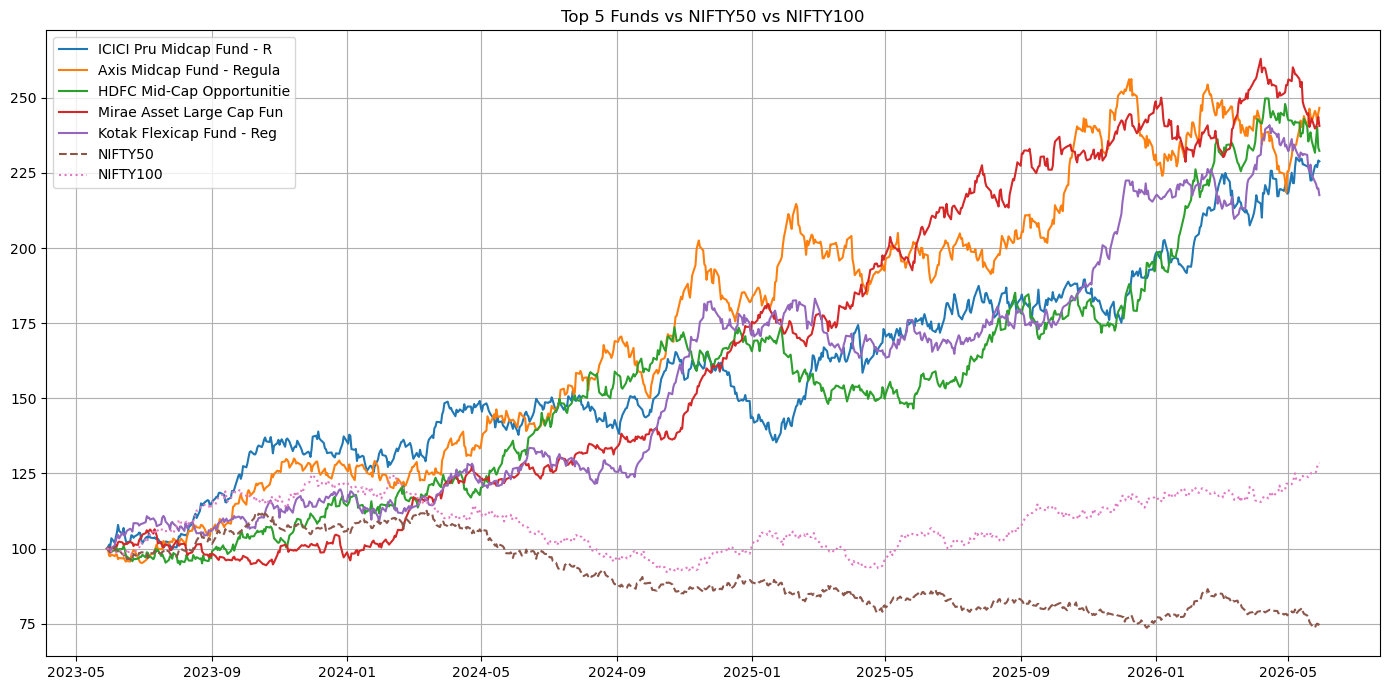

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

for code in top5_codes:

    temp = nav[
        (nav["amfi_code"] == code) &
        (nav["date"] >= start_date)
    ].copy()

    temp = temp.sort_values("date")

    normalized = (
        temp["nav"] /
        temp["nav"].iloc[0]
    ) * 100

    fund_name = scorecard[
        scorecard["amfi_code"] == code
    ]["scheme_name"].iloc[0]

    plt.plot(
        temp["date"],
        normalized,
        label=fund_name[:25]
    )

# NIFTY50
n50 = nifty50[
    nifty50["date"] >= start_date
].copy()

n50_norm = (
    n50["close_value"] /
    n50["close_value"].iloc[0]
) * 100

plt.plot(
    n50["date"],
    n50_norm,
    linestyle="--",
    label="NIFTY50"
)

# NIFTY100
n100 = nifty100[
    nifty100["date"] >= start_date
].copy()

n100_norm = (
    n100["close_value"] /
    n100["close_value"].iloc[0]
) * 100

plt.plot(
    n100["date"],
    n100_norm,
    linestyle=":",
    label="NIFTY100"
)

plt.title(
    "Top 5 Funds vs NIFTY50 vs NIFTY100"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "reports/charts/benchmark_comparison.png"
)

plt.show()

In [69]:
nifty100["benchmark_return"] = (
    nifty100["close_value"]
           .pct_change()
)

In [70]:
tracking_error_results = []

for code, grp in nav.groupby("amfi_code"):

    merged = pd.merge(
        grp,
        nifty100[
            ["date","benchmark_return"]
        ],
        on="date"
    )

    merged = merged.dropna()

    diff = (
        merged["daily_return"]
        -
        merged["benchmark_return"]
    )

    tracking_error = (
        diff.std()
        * np.sqrt(252)
    )

    tracking_error_results.append([
        code,
        tracking_error
    ])

tracking_error_df = pd.DataFrame(
    tracking_error_results,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_error_df.head()

,amfi_code,tracking_error
0,100016,0.199284
1,100025,0.134535
2,100033,0.228699
3,101206,0.192706
4,101207,0.292117


In [71]:
cagr_df.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


In [72]:
cagr_df.to_csv(
    "reports/cagr_comparison.csv",
    index=False
)

In [73]:
import os

os.path.exists("reports/cagr_comparison.csv")

True

In [74]:
import os

print(os.listdir("reports"))

print(os.listdir("reports/charts"))

['alpha_beta.csv', 'amfi_validation_summary.txt', 'cagr_comparison.csv', 'charts', 'data_dictionary.md', 'day1_data_quality_report.txt', 'fund_master_summary.txt', 'fund_scorecard.csv', 'reports']
['age_group_distribution.png', 'aum_growth.png', 'benchmark_comparison.png', 'category_heatmap.png', 'category_inflow_bar.png', 'folio_growth.png', 'gender_distribution.png', 'monthly_avg_nav.png', 'nav_correlation_heatmap.png', 'nav_trend.html', 'sector_allocation_donut.png', 'sip_boxplot_agegroup.png', 'sip_trend.html', 'sip_trend_matplotlib.png', 'state_investment_distribution.png', 't30_b30_distribution.png', 'top10_avg_nav.png', 'transaction_type_distribution.png']


In [1]:
import pandas as pd

perf = pd.read_csv("data/processed/scheme_performance_clean.csv")
txn = pd.read_csv("data/processed/investor_transactions_clean.csv")

print("PERF COLUMNS")
print(perf.columns.tolist())

print("\nTXN COLUMNS")
print(txn.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/scheme_performance_clean.csv'

In [2]:
print(perf.columns.tolist())
print(txn.columns.tolist())

NameError: name 'perf' is not defined

In [3]:
import os

print(os.getcwd())

c:\bluestock_mf_capstone\notebooks\outputs\charts


In [4]:
import pandas as pd

perf = pd.read_csv(
    "../../../data/processed/scheme_performance_clean.csv"
)

txn = pd.read_csv(
    "../../../data/processed/investor_transactions_clean.csv"
)

print("PERF COLUMNS")
print(perf.columns.tolist())

print("\nTXN COLUMNS")
print(txn.columns.tolist())

PERF COLUMNS
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

TXN COLUMNS
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [5]:
import os

for root, dirs, files in os.walk("C:/bluestock_mf_capstone/data"):
    for f in files:
        print(os.path.join(root, f))

C:/bluestock_mf_capstone/data\db\bluestock_mf.db
C:/bluestock_mf_capstone/data\processed\investor_transactions_clean.csv
C:/bluestock_mf_capstone/data\processed\nav_history_clean.csv
C:/bluestock_mf_capstone/data\processed\scheme_performance_clean.csv
C:/bluestock_mf_capstone/data\raw\01_fund_master.csv
C:/bluestock_mf_capstone/data\raw\02_nav_history.csv
C:/bluestock_mf_capstone/data\raw\03_aum_by_fund_house.csv
C:/bluestock_mf_capstone/data\raw\04_monthly_sip_inflows.csv
C:/bluestock_mf_capstone/data\raw\05_category_inflows.csv
C:/bluestock_mf_capstone/data\raw\06_industry_folio_count.csv
C:/bluestock_mf_capstone/data\raw\07_scheme_performance.csv
C:/bluestock_mf_capstone/data\raw\08_investor_transactions.csv
C:/bluestock_mf_capstone/data\raw\09_portfolio_holdings.csv
C:/bluestock_mf_capstone/data\raw\10_benchmark_indices.csv
C:/bluestock_mf_capstone/data\raw\Axis_Bluechip.csv
C:/bluestock_mf_capstone/data\raw\ICICI_Bluechip.csv
C:/bluestock_mf_capstone/data\raw\Kotak_Bluechip.csv
C: